In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
import time


In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import torch.nn.functional as F


In [3]:
batch_size = 64
use_subset = False
subset_size = 20000

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # mean/std for MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
if use_subset:
    # Stratified subset to preserve label balance
    X = np.array(train_dataset.data)
    y = np.array(train_dataset.targets)
    sss = StratifiedShuffleSplit(n_splits=1, train_size=subset_size, random_state=42)
    for train_idx, _ in sss.split(X, y):
        subset_indices = train_idx
    train_dataset1 = Subset(train_dataset, subset_indices)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [ ]:
train_dataset


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [41]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 30)
        self.fc2 = nn.Linear(30, 20)
        self.fc3 = nn.Linear(20, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
def train_model(model,train_loader,criterion,optimizer,device,epochs=10):
  model.to(device)

  for epoch in range(epochs):
      model.train()
      running_loss = 0.0
      correct = 0
      total = 0

      for images, labels in train_loader:

          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          running_loss += loss.item()

          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train_Accuracy: {100*correct /total:.2f}%")

In [8]:
def evaluate_model(model,test_loader,device):
  model.eval()
  correct, total = 0, 0
  all_preds = []
  all_labels = []
  start_time = time.time()
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, preds = torch.max(outputs, 1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)
          all_preds.append(preds.cpu())
          all_labels.append(labels.cpu())

  inference_time = time.time() - start_time
  # Concatenate all batches
  all_preds = torch.cat(all_preds).numpy()
  all_labels = torch.cat(all_labels).numpy()
  f1_macro = f1_score(all_labels, all_preds, average='macro')
  f1_weighted = f1_score(all_labels, all_preds, average='weighted')
  cm = confusion_matrix(all_labels, all_preds)
  acc = 100 * correct / total
  print(f"Test Accuracy: {acc:.4f}%")
  print(f"F1 Score (macro): {f1_macro:.4f}")
  print(f"F1 Score (weighted): {f1_weighted:.4f}")


  return acc, f1_macro, f1_weighted,cm,inference_time

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
criterion = nn.CrossEntropyLoss()

In [42]:
model = MLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [43]:
train_model(model=model,train_loader=train_loader,criterion=criterion,optimizer=optimizer,device=device,epochs=15)

Epoch [1/15], Loss: 0.4023, Train_Accuracy: 88.41%
Epoch [2/15], Loss: 0.1948, Train_Accuracy: 94.36%
Epoch [3/15], Loss: 0.1605, Train_Accuracy: 95.30%
Epoch [4/15], Loss: 0.1394, Train_Accuracy: 95.94%
Epoch [5/15], Loss: 0.1246, Train_Accuracy: 96.26%
Epoch [6/15], Loss: 0.1140, Train_Accuracy: 96.57%
Epoch [7/15], Loss: 0.1047, Train_Accuracy: 96.84%
Epoch [8/15], Loss: 0.0967, Train_Accuracy: 97.04%
Epoch [9/15], Loss: 0.0913, Train_Accuracy: 97.17%
Epoch [10/15], Loss: 0.0848, Train_Accuracy: 97.37%
Epoch [11/15], Loss: 0.0788, Train_Accuracy: 97.55%
Epoch [12/15], Loss: 0.0750, Train_Accuracy: 97.62%
Epoch [13/15], Loss: 0.0718, Train_Accuracy: 97.72%
Epoch [14/15], Loss: 0.0679, Train_Accuracy: 97.83%
Epoch [15/15], Loss: 0.0656, Train_Accuracy: 97.88%


In [44]:
test_accuracy,f1_mlp_macro,f1_mlp_weighted,cm_mlp,inference_time_mlp = evaluate_model(model, test_loader, device)


Test Accuracy: 96.0700%
F1 Score (macro): 0.9603
F1 Score (weighted): 0.9607


In [45]:
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

use_subset = False
subset_size = 20000

if use_subset:
    # original MNIST tensors
    X = train_dataset.data
    y = train_dataset.targets

    sss = StratifiedShuffleSplit(n_splits=1, train_size=subset_size, random_state=42)
    for train_idx, _ in sss.split(X, y):
        subset_indices = train_idx

    # extract subset data and labels as numpy arrays
    X_train = X[subset_indices].numpy().reshape(-1, 28*28)
    y_train = y[subset_indices].numpy()
else:
    # full dataset
    X_train = train_dataset.data.numpy().reshape(-1, 28*28)
    y_train = train_dataset.targets.numpy()

# test set
X_test = test_dataset.data.numpy().reshape(-1, 28*28)
y_test = test_dataset.targets.numpy()


In [46]:
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1)
model_lr.fit(X_train,y_train)
y_predlr = model_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test,y_predlr)
print(f"Logistic Regression Test Accuracy: {accuracy_lr*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Test Accuracy: 92.03%


In [58]:
f1_weighted_lr = f1_score(y_test, y_predlr, average='weighted')
f1_macro_lr = f1_score(y_test, y_predlr, average='macro')

In [50]:
cm2 = confusion_matrix(y_test,y_predlr)


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
cm3 = confusion_matrix(y_test,y_pred_rf)
print(f"Random Forest Test Accuracy: {acc_rf*100:.4f}%")



Random Forest Test Accuracy: 97.0500%


In [55]:
cm3 = confusion_matrix(y_test,y_pred_rf)


## comparison table and confusion matrix-mlp,LR,Rf

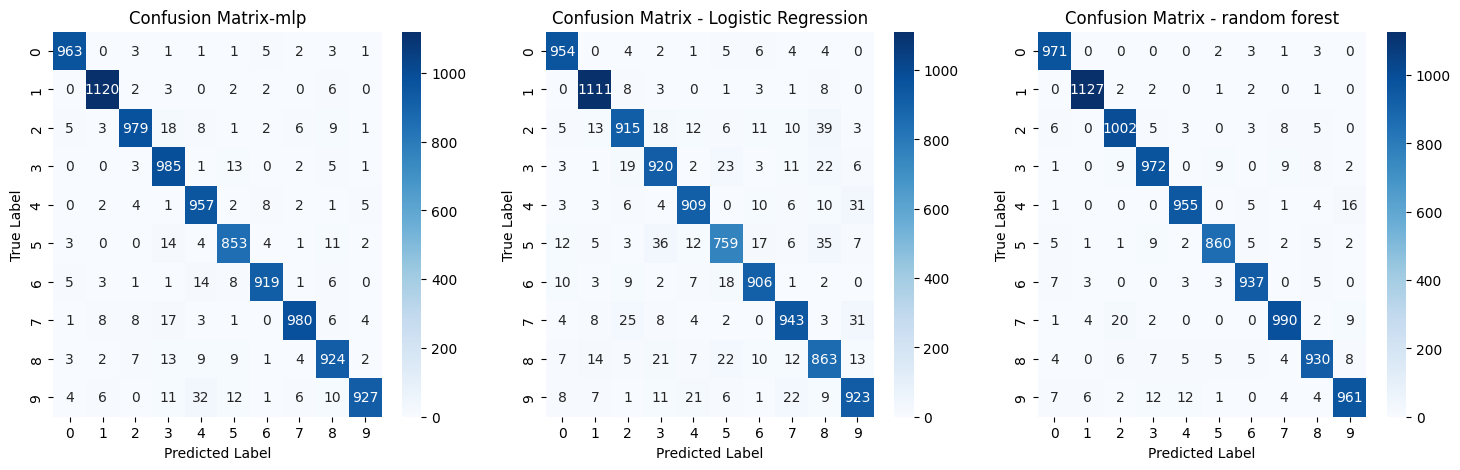

In [56]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix-mlp')
plt.subplot(1,3,2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.subplot(1,3,3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - random forest')
plt.show()

In [59]:
print(f"{'Model':<20}{'Accuracy (%)':<15}{'F1 macro':<15}{'F1 weighted':<15}")
print("-"*65)
print(f"{'MLP':<20}{test_accuracy:<15.2f}{f1_mlp_macro:<15.4f}{f1_mlp_weighted:<15.4f}")
print(f"{'Logistic Regression':<20}{accuracy_lr:<15.2f}{f1_macro_lr:<15.4f}{f1_weighted_lr:<15.4f}")
print(f"{'Random Forest':<20}{acc_rf:<15.2f}{f1_macro_rf:<15.4f}{f1_score_rf:<15.4f}")

Model               Accuracy (%)   F1 macro       F1 weighted    
-----------------------------------------------------------------
MLP                 96.07          0.9603         0.9607         
Logistic Regression 0.92           0.9191         0.9201         
Random Forest       0.97           0.9703         0.9705         


**OBSERVATIONS:**


1. Random Forest is highly effective for tabular data or datasets where features are well-separated, which is why it slightly outperforms MLP here.

2. MLP still performs very well,
showing neural networks can capture patterns even without very deep architectures.

3. Logistic Regression, being a simpler linear model, struggles to reach the same performance.

* **MLP model:**
1. digit 9 is often misclassified as 4 many a times,and it is misclassified as 3,5 too..they are in similar shapes.digit 5 is sometimes misclassified as 3 or 8.similarly digit 2 is predicted as 3 most in its misclassfications.
2. The misclassifications are sparse and mostly between visually similar digits in mlp.
* **Logistic regression:**
1. Digit 5 is frequently misclassified as 3, 6, or 8.
Digit 7 is confused with 2 and 1.Digit 4 is confused with 9 and 6.
2. logistic regression struggles with complex shapes; linear decision boundaries are insufficient for some digits.
* **Randomforest model**:
1. there are very few misclassifications.Digit 7 predicts
as 2 occcasionally.Digit 5 predicted as 6 occasionally. Digit 4 predicted as 9 or 8 sometimes.
2. Random Forest is most accurate, misclassifies only a handful of samples, mostly visually similar digits.








# TSNE



In [ ]:
def get_hidden_activations(model, data_loader, device):
    model.eval()
    activations = []
    labels = []

    with torch.no_grad():
        for images, lbls in data_loader:
            images = images.to(device)
            x = model.flatten(images)
            x = model.relu(model.fc1(x))
            x = model.relu(model.fc2(x))  # 20-neuron layer
            activations.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    activations = np.vstack(activations)
    labels = np.hstack(labels)
    return activations, labels

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(activations, labels, title="t-SNE"):
    tsne = TSNE(n_components=2, random_state=42)   # Reduce activations to 2D using t-SNE and plot them.
    X_embedded = tsne.fit_transform(activations)

    plt.figure(figsize=(8,6))
    for digit in range(10):
        idxs = labels == digit
        plt.scatter(X_embedded[idxs,0], X_embedded[idxs,1], label=str(digit), alpha=0.6)
    plt.legend()
    plt.title(title)
    plt.show()

In [ ]:
from torch.utils.data import Subset, DataLoader

subset_loader = DataLoader(Subset(test_dataset, range(2000)), batch_size=128, shuffle=False)


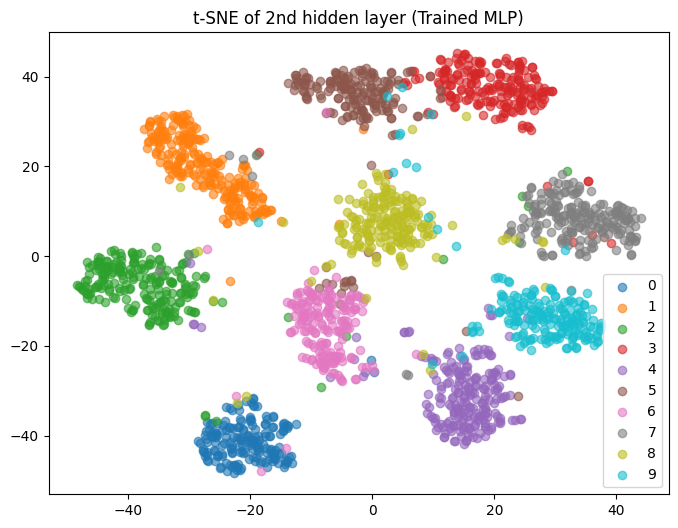

In [ ]:
trained_activations, trained_labels = get_hidden_activations(model,subset_loader, device)
plot_tsne(trained_activations, trained_labels, title="t-SNE of 2nd hidden layer (Trained MLP)")

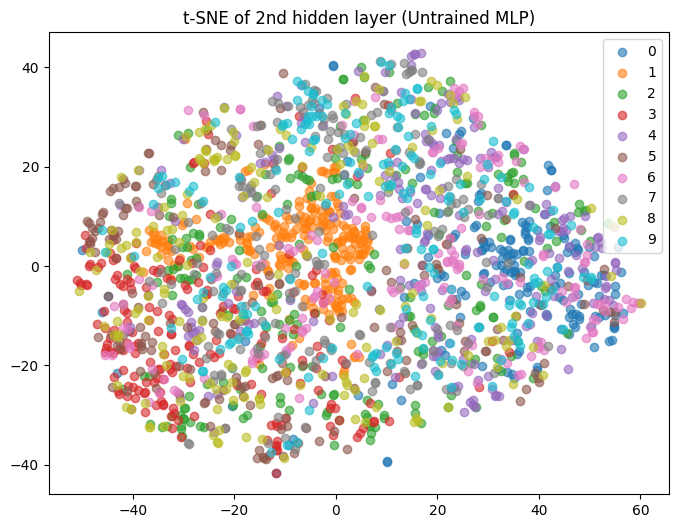

In [ ]:
untrained_model = MLP()
untrained_model.to(device)

untrained_activations, untrained_labels = get_hidden_activations(untrained_model, subset_loader, device)
plot_tsne(untrained_activations, untrained_labels, title="t-SNE of 2nd hidden layer (Untrained MLP)")

In [ ]:
transform1 = transforms.ToTensor()

In [ ]:
fashion_test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform1)
fashion_test_loader = DataLoader(fashion_test_dataset, batch_size=128, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


In [ ]:
fashion_subset_loader = DataLoader(Subset(fashion_test_dataset, range(2000)), batch_size=128, shuffle=False)

In [ ]:
evaluate_model(model, fashion_subset_loader, device)

Test Accuracy: 5.3000%
F1 Score (macro): 0.0522
F1 Score (weighted): 0.0500


(5.3,
 0.052195234498434516,
 0.049986742110219945,
 array([[  0,   0,   0,   1,   0, 188,   1,   5,   3,   2],
        [  0,   0,   0,  30,   0, 160,   0,   4,   0,   9],
        [  7,   0,   0,   0,   0, 155,  48,   1,   2,   1],
        [  1,   0,   0,  60,   0, 124,   0,   1,   3,   1],
        [  6,   0,   0,   0,   0, 157,  47,   1,   2,   6],
        [  7,   1, 118,   6,   3,  31,  17,  11,   1,   0],
        [  2,   0,   0,   1,   0, 175,  14,   1,   0,   4],
        [  0,   0, 179,   0,   4,   1,  16,   0,   0,   0],
        [ 42,   0,   4,   4,   2,  97,  32,   4,   1,   8],
        [  0,   0, 146,  16,   0,  26,   0,   0,   0,   0]]))

In [ ]:
fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
fashion_activations, fashion_labels = get_hidden_activations(model, fashion_test_loader, device)

In [ ]:
fashion_labels_names = [fashion_classes[label] for label in fashion_labels]

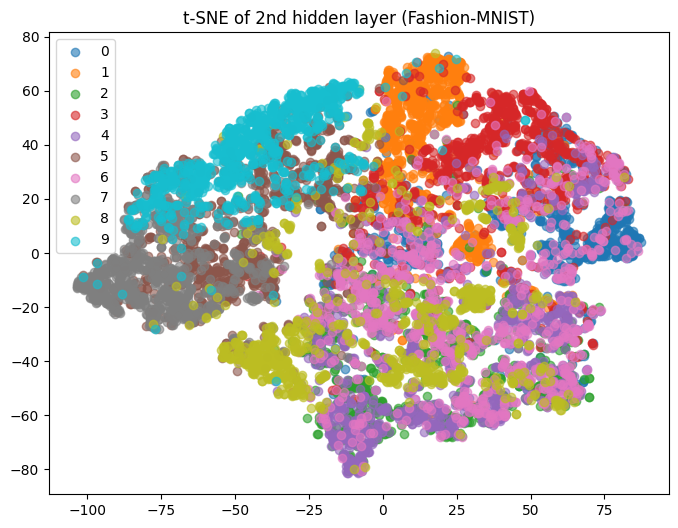

In [ ]:
plot_tsne(fashion_activations, fashion_labels, title="t-SNE of 2nd hidden layer (Fashion-MNIST)")

# Fashion mnist& tsne observations

**Fashion mnist dataset tested on mnist trained mlp**:
1. The MLP learned features specific to handwritten digits — strokes, curves, and shapes that define numbers.The mlp model has effectively memorized “digit shapes”, not learned general visual patterns like edges, corners, or textures that work for different kinds of images.
2. Fashion-MNIST images (shirts, shoes, bags, etc.) look completely different — textures, edges, and patterns unlike digits.
3. Since the model never saw anything like that, it can't make sense of these inputs; it will produce random or meaningless predictions.(reason for test accuracy ~5%)
4. The features the MLP learned from MNIST don't transfer well to Fashion-MNIST.
5. It shows that MNIST features are task-specific, not general visual features.


* **for untrained mlp**:
1. since the weights are initally randomly initializaed,so the embeddings are essentially random projections of the input space.
2. There is no learned structure ,so the t-SNE will not reveal any meaningful separation.
* **for trained mlp**:
1. The t-SNE plot for MNIST usually shows well-separated, compact clusters for each digit (0 -9).
2. Some overlap may exist between 4 and 9, or 3 and 5, but overall the structure is clear.
3. The neural network has learned well to separate the data for different classes clearly inside its hidden layer.
4. Digits have simple shapes and highly consistent structure across samples.
5. The MLP can easily separate the latent features for each class.
6. The embeddings are well-organized — t-SNE shows tight, distinct islands.
* **for fashion mnist**:
1. t-SNE shows that the 20-neuron embeddings for Fashion-MNIST are partially clustered but highly overlapping, unlike MNIST where clusters are well-separated.
2. It is because the MLP is trained on mnist and learned features that are specific to MNIST digits. It does not generalize to Fashion-MNIST, but still produces some organized activations due to the network's internal structure.
3. If we train the same MLP on Fashion-MNIST, the t-SNE clusters will separate properly by clothing classes, showing that the network can learn dataset-specific embeddings.

# CNN


In [12]:
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize grayscale images
])

In [13]:
train_data_cnn = datasets.MNIST(root='./data', train=True, transform=transform_cnn, download=True)
test_data_cnn = datasets.MNIST(root='./data', train=False, transform=transform_cnn)
train_loader1 = DataLoader(train_data_cnn, batch_size=64, shuffle=True)
test_loader1 = DataLoader(test_data_cnn, batch_size=1000, shuffle=False)

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)  # Conv layer: input 1x28x28 → output 32x26x26 (no padding)
        self.pool = nn.MaxPool2d(2, 2)  # 32x13x13 after pooling
        self.fc1 = nn.Linear(32 * 13 * 13, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv + relu + pool
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))               # fully connected + relu
        x = self.fc2(x)                       # output layer
        return x

In [15]:
model_cnn = CNN().to(device)

In [16]:
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

In [19]:
num_epochs = 5
for epoch in range(num_epochs):
    model_cnn.train()
    correct = 0
    total = 0
    running_loss1 = 0.0
    for images, labels in train_loader1:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss1 += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss1/len(train_loader1):.4f},Train Accuracy:{100*correct/total: .4f}%")

Epoch [1/5], Loss: 0.2030,Train Accuracy: 94.0350%
Epoch [2/5], Loss: 0.0659,Train Accuracy: 97.9917%
Epoch [3/5], Loss: 0.0438,Train Accuracy: 98.6233%
Epoch [4/5], Loss: 0.0315,Train Accuracy: 98.9983%
Epoch [5/5], Loss: 0.0239,Train Accuracy: 99.2117%


In [20]:
model_cnn.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader1:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.17%


In [21]:
test_accuracy,f1_cnn_macro,f1_cnn_weighted,cm_cnn,inferencetime_cnn = evaluate_model(model_cnn, test_loader1, device)

Test Accuracy: 98.1700%
F1 Score (macro): 0.9815
F1 Score (weighted): 0.9817


In [23]:
transform4= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset2 = datasets.MNIST(root='./data', train=False, transform=transform4, download=True)
test_loader2 = DataLoader(test_dataset2, batch_size=64, shuffle=False)

In [25]:
from torchvision import datasets, transforms, models

In [29]:
alexnet = models.alexnet(pretrained=True)
# Replace final layer for 10 MNIST classes
alexnet.classifier[6] = nn.Linear(alexnet.classifier[6].in_features, 10)
alexnet.to(device).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 194MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [30]:
test_acc_alexnet,f1_alex_macro,f1_alex_weighted,cm_alexnet,inferencetime_alexnet = evaluate_model(alexnet, test_loader2, device)

Test Accuracy: 13.4000%
F1 Score (macro): 0.0459
F1 Score (weighted): 0.0480


In [26]:
efficientnet = models.efficientnet_b0(pretrained=True)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 10)
efficientnet.to(device).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 207MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
test_acc_effnet,f1_effnet_macro,f1_effnet_weighted,cm_effnet,inferencetime_efficientnet = evaluate_model(efficientnet
                                                                                                         , test_loader2, device)

Test Accuracy: 9.1500%
F1 Score (macro): 0.0261
F1 Score (weighted): 0.0265


In [31]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

params_cnn = count_params(model_cnn)
params_alex = count_params(alexnet)
params_eff = count_params(efficientnet)

print(f"Custom CNN: {params_cnn:,} params")
print(f"AlexNet: {params_alex:,} params")
print(f"EfficientNet-B0: {params_eff:,} params")

Custom CNN: 693,962 params
AlexNet: 57,044,810 params
EfficientNet-B0: 4,020,358 params


##Comparison tables - CNN,ALEXnet,Efficient net

In [39]:
print(f"{'Model':<15}{'Accuracy (%)':<15}{'F1 macro':<15}{'F1 weighted':<15}{'Params ':<15}{'Inference Time (s)':<15}")
print("-"*90)
print(f"{'Custom CNN':<15}{test_accuracy:<15.2f}{f1_cnn_macro:<15.4f}{f1_cnn_weighted:<15.4f}{params_cnn:<15}{inferencetime_cnn:<15.2f}")
print(f"{'AlexNet':<15}{test_acc_alexnet:<15.2f}{f1_alex_macro:<15.4f}{f1_alex_weighted:<15.4f}{params_alex:<15}{inferencetime_alexnet:<15.2f}")
print(f"{'EfficientNetB0':<15}{test_acc_effnet:<15.2f}{f1_effnet_macro:<15.4f}{f1_effnet_weighted:<15.4f}{params_eff:<15}{inferencetime_efficientnet:<15.2f}")


Model          Accuracy (%)   F1 macro       F1 weighted    Params         Inference Time (s)
------------------------------------------------------------------------------------------
Custom CNN     98.17          0.9815         0.9817         693962         2.31           
AlexNet        13.40          0.0459         0.0480         57044810       20.87          
EfficientNetB0 9.15           0.0261         0.0265         4020358        28.47          


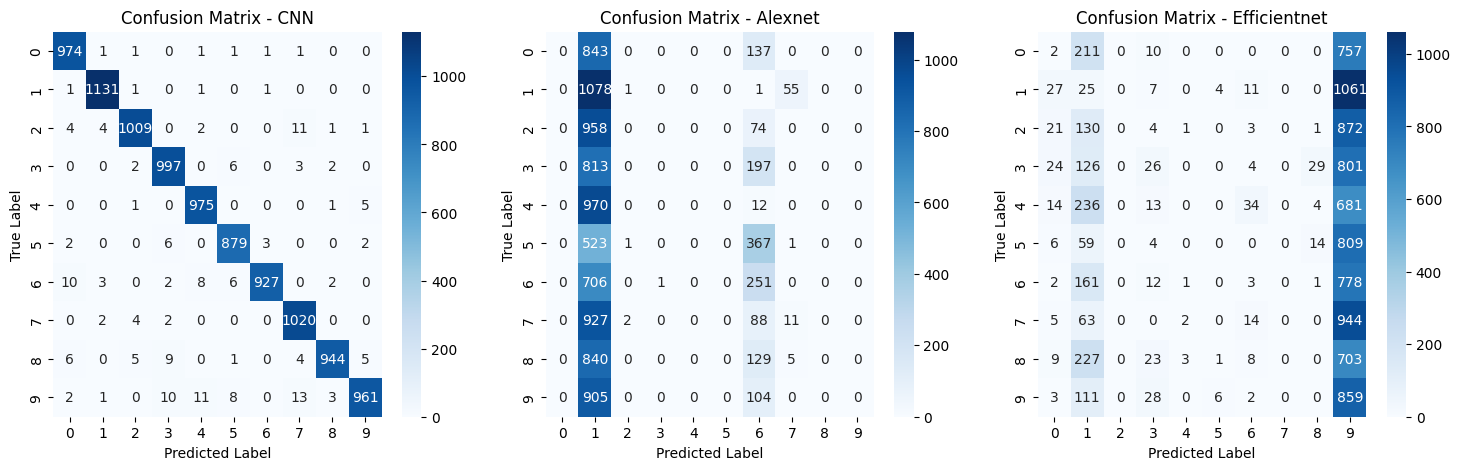

In [34]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN')
plt.subplot(1,3,2)
sns.heatmap(cm_alexnet, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Alexnet')
plt.subplot(1,3,3)
sns.heatmap(cm_effnet, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Efficientnet')
plt.show()

**Observations**:
1. The CNN achieved the highest accuracy (98.17%) and the best F1-scores (macro: 0.9815, weighted: 0.9817).
2. Both AlexNet and EfficientNetB0 performed very poorly on the MNIST dataset, with accuracies of 13.40% and 9.15%, respectively.
Their F1-scores are extremely low, indicating that they failed to classify digits correctly.
3. AlexNet and EfficientNetB0 are pretrained on ImageNet (natural RGB images with 3 color channels and complex textures).MNIST images are grayscale and simple (handwritten digits).
4. Without fine-tuning or retraining, these pretrained models cannot generalize to the MNIST domain, leading to almost random predictions.
5. The CNN is very lightweight (~0.7 million parameters) compared to AlexNet (57 million) and EfficientNetB0 (4 million).
6. Despite being much smaller, it performed dramatically better, showing that task-specific, simple models can outperform large, mismatched pretrained models.
7.  CNN had the fastest inference time andAlexNet and EfficientNetB0 were much slower, due to their deeper architectures and larger parameter counts.
8. The CNN is most accurate, efficient, and appropriate for MNIST.
Pretrained models like AlexNet and EfficientNetB0 are not suitable for direct inference on grayscale datasets without adaptation.
9. Simpler architectures often perform better and faster when the data domain is simple and well-defined.